<a href="https://colab.research.google.com/github/Israel-Garcilazo/Investigaci-n-de-operaciones-2/blob/main/tutorial_1_de_networkx.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial 1 de **NetworkX**

**Actividad 1 — Investigación de Operaciones**

En este cuaderno vamos a ver cómo poder programar un diagrama de redes y resolverlo mediante el uso de la biblioteca de Python, **Netowrkx**, para los siguientes tres método:

1. **Árbol de expansión mínima**.
2. **Ruta más corta**.
3. **Flujo máximo**.

Lo primero que se debe de hacer es construir el arreglo que se entenderá como el diagrama. Luego se aplicarán las soluciones directas que ofrece dicha biblioteca.


## ¿Cómo se usa NetworkX?

`NetworkX` forma parte de las bibliotecas de Python y sirve para **crear y resolver problemas redes**.

Las funciones más utilizadas para los ejercicios revisados en este tutorial serán los siguientes:

- `nx.Graph()` → sirve para definir un nodo **no dirigido**.
- `nx.DiGraph()` → sirve para definir un nodo **dirigido**.
- `G.add_edge(u, v, weight=w)` → sirve para agregar una arista con flujo `w` (la biblioteca considera a "w" como "weigtht").
- `G.add_edge(u, v, capacity=c)` → agrega un arco con capacidad `c`.
- `nx.minimum_spanning_tree(...)` → calcula de forma directa el árbol de expansión mínima de un arreglo de nodos y aristas.
- `nx.shortest_path(...)` → calcula la ruta de menor costo dado un arreglo de nodos y aristas.
- `nx.maximum_flow(...)` → calcula la ruta de mmáximo flujo dado un arreglo de nodos y aristas.


In [1]:
import networkx as nx
import matplotlib.pyplot as plt


### ¿Cómo hacer una arista con flujo/capacidad?

Un nodo se puede definir ante la biblioteca de la siguiente forma:

```python
G.add_edge(1, 2, weight=5)
```

significa que existe una conexión entre los nodos `1` y `2` cuyo atributo `flujo/weight` vale `5`.

Para una red de flujo con capacidad:

```python
G.add_edge(1, 2, capacity=8)
```

significa que el arco `1 → 2` tiene capacidad máxima `8`.

---
# 1. Método del árbol de expansión mínima

## 1.1. Formulación matemática del problema del árbol de expasión mínima

Se puede definir de forma formal al árbol de expasión mínima de la siguiente forma:

Sea un grafo conexo no dirigido

$$G=(V,E)$$

con un costo/peso $w_{ij}$ asociado a cada arista. Un **árbol de expansión** debe:

- conectar todos los vértices,
- no contener ciclos,

El **árbol de expansión mínima** es el árbol $T\subseteq E$ que minimiza

$$
\min_{T}\sum_{(i,j)\in T} w_{ij}.
$$

### Actividad 1(a)

Buscamos resolver la siguiente red:

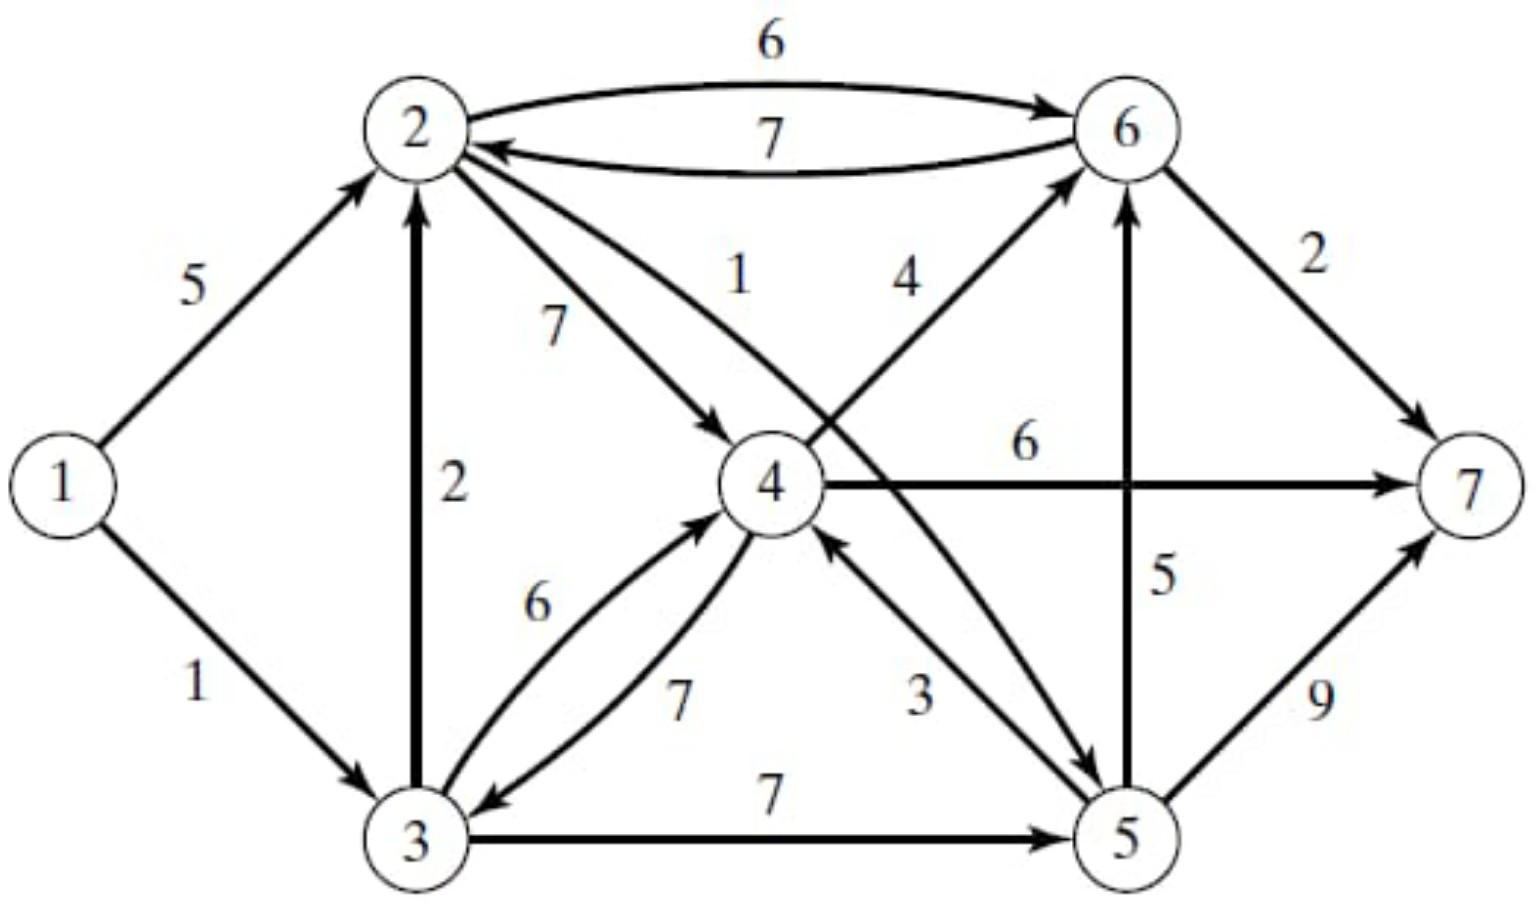

In [2]:
# Abrimos la función que guardará la información del diagrama de flujo.
G = nx.Graph()

# Creamos la variedad de aristas visualizadas en el diagrama.
aristas = [
    (1, 2, 5), (1, 3, 1), (3, 2, 2),
    (2, 4, 7), (2, 5, 1), (3, 4, 6),
    (4, 3, 7), (3, 5, 7), (4, 6, 4),
    (2, 6, 6), (6, 2, 7), (4, 7, 6),
    (6, 7, 2), (5, 6, 5), (5, 4, 3),
    (5, 7, 9)
]

# Mediante un ciclo for, guardamos las distintas aristas en una función que servirá para graficar.
for u, v, w in aristas:
    G.add_edge(u, v, weight=w)


**NOTA**: para la variable `pos` mostrada a continuación, se está declarando la creación de nodos en el formato:

$$
i: (x, y), i = 1,2, ..., n-nodos.
$$

Es decir que el entorno genera un plano cartesiano en el que acomodará los nodos según los valores de $x$ y $y$ que se le den en cada cordenada asociada.



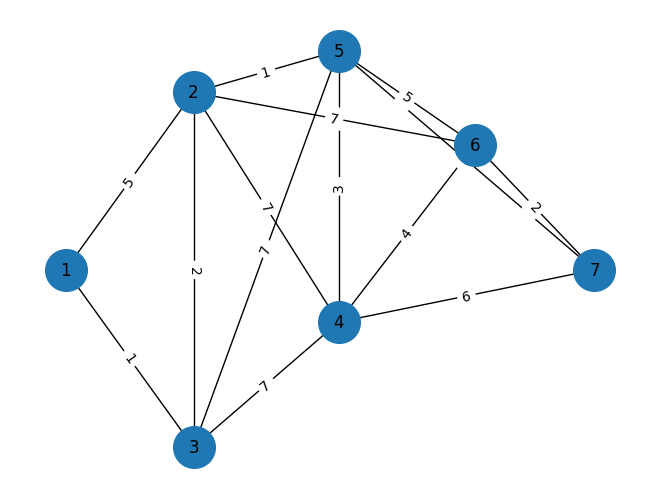

In [3]:
pos = {
    1: (0, 0), 2: (1.5, 1.7), 3: (1.5, -1.7),
    4: (3.2, -0.5), 5: (3.2, 2.1), 6: (4.8, 1.2),
    7: (6.2, 0)
}

# Líneas para gráficar el diagrama de flujo.
nx.draw(G, pos, with_labels=True, node_size=900)
nx.draw_networkx_edge_labels(G, pos,
    edge_labels=nx.get_edge_attributes(G, 'weight'))
plt.show()


## 1.2. Solución del arbol de expansión mínima.

La función que se usa es:

```python
nx.minimum_spanning_tree(G, weight='weight')
```

Se usará a continuación con la red anterior.

In [4]:
# Variable para poder guardar los valores del árbol de expansión mínima.
T = nx.minimum_spanning_tree(G, weight='weight')

#Imprimimos los resultados.
print("Aristas del árbol mínimo:")
print(list(T.edges(data=True)))
print("Costo total:", T.size(weight='weight'))


Aristas del árbol mínimo:
[(1, 3, {'weight': 1}), (2, 5, {'weight': 1}), (2, 3, {'weight': 2}), (4, 5, {'weight': 3}), (4, 6, {'weight': 4}), (6, 7, {'weight': 2})]
Costo total: 13.0


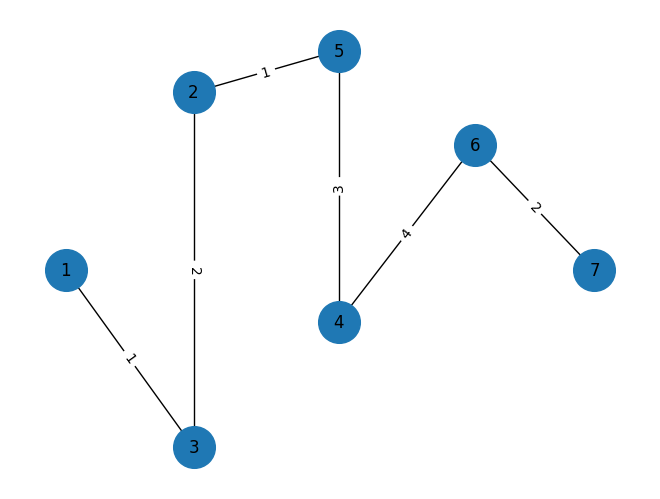

In [5]:
# Gráficamos el resultado.
nx.draw(T, pos, with_labels=True, node_size=900)
nx.draw_networkx_edge_labels(T, pos,
    edge_labels=nx.get_edge_attributes(T, 'weight'))
plt.show()


### Resultados

El árbol encontrado utiliza **6 líneas de flujo**, como debe ocurrir en un árbol que conecta los 7 nodos.

El flujo total del árbol de expasión mínima es:

$$
\boxed{1+1+2+2+3+4=13}
$$



---
# 2. Ruta más corta

## 2.1. Formulación matemática del problema de la ruta más corta.

En un grafo dirigido con pesos no negativos, la ruta más corta entre un origen $s$ y un destino $t$ es una secuencia de nodos que minimiza

$$
\min_{P:s\to t}\sum_{(i,j)\in P} w_{ij}.
$$

Por convención, se toma:

$$s=1,\qquad t=7.$$

Lo que significa que $s$ será nuestro nodo inicial y $t$ será el nodo final.

De manera interna, las funciones `nx.shortest_path()` y `nx.shortest_path_length()` resuelve el problema con el algoritmo de Dijkstra.

In [6]:
# Ahora hacemos la versión dirigida del diagrama de la actividad 1(a).
D = nx.DiGraph()
D.add_weighted_edges_from(aristas)


In [7]:
# Definimos los parámetros inicilaes para trabajar el método.
origen = 1
destino = 7

# Usamos las dos funciones de la biblioteca para resolver estos problemas.
ruta = nx.shortest_path(D, origen, destino, weight='weight')
costo = nx.shortest_path_length(D, origen, destino, weight='weight')

print("Ruta más corta:", ruta)
print("Costo total:", costo)


Ruta más corta: [1, 3, 2, 6, 7]
Costo total: 11


**NOTA**: si desea cambiar el nodo de inicio y final, basta con modificar el valor de $origen$ y $destino$, las funciones `nx.shortest_path()` y `nx.shortest_path_length()` siguen calculando un resultado sin importar quienes sean los iniciales y finales.

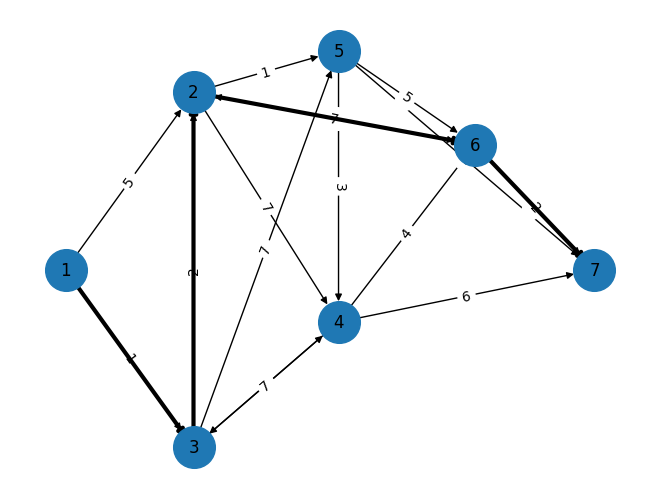

In [8]:
#Líneas de graficación.
nx.draw(D, pos, with_labels=True, node_size=900, arrows=True)
nx.draw_networkx_edge_labels(D, pos,
    edge_labels=nx.get_edge_attributes(D, 'weight'))

aristas_ruta = list(zip(ruta[:-1], ruta[1:]))
nx.draw_networkx_edges(D, pos, edgelist=aristas_ruta,
                       width=3)
plt.show()


In [9]:
# Guardamos en una variable las rutas mínimas que los comandos anterior hayan encontrado.
# Al meterse en una lista, si existe más de una ruta con el mismo valore, imprimirá todas las rutas que cmpartan el mínimo valor.
rutas_minimas = list(nx.all_shortest_paths(D, origen, destino, weight='weight'))
print("Rutas mínimas:")
for r in rutas_minimas:
    print(r)


Rutas mínimas:
[1, 3, 2, 6, 7]
[1, 3, 2, 5, 6, 7]


### Resultados

La mejor ruta es entonces:

$$
1\rightarrow3\rightarrow2\rightarrow6\rightarrow7
$$

con flujo mínimo de:

$$
1+2+6+2=11.
$$

Se ha elegido esa porque, pese a tener el mismo flujo que la otra, es la que menos nodos involucra. Pese a eso, ambas soluciones siguen siendo óptimas.

---
# 3. Flujo máximo

## 3.1. Formulación matemática del problema de flujo máximo.

En una red dirigida $G=(V,E)$ se tiene:

- una **origen** $s$,
- un **destino** $t$,
- una capacidad $c_{ij}$ para cada arco.

Queremos determinar cuánto flujo puede salir de $s$ y llegar a $t$ sin exceder las capacidades.

Si $f_{ij}$ representa el flujo por el arco $i\to j$, entonces:

$$
0\le f_{ij}\le c_{ij}
$$

para todo arco, y para cada nodo intermedio se cumple conservación de flujo:

$$
\sum_{j} f_{ji}=\sum_{j} f_{ij}.
$$

El objetivo es maximizar el flujo neto que sale de la fuente:

$$
\max |f|.
$$


## 3.2. Construcción de la red de la actividad 1(b)

Para representar la capacidad máxima contra la capacidad actual ocupada de un flujo entre un nodo y otro, se puede usar la siguiente notación:

```latex
\draw (1) -- node[...] {14} node[...] {0} (3);
```

Que se puede interpretar como:

$$c_{1,3}=14,\qquad c_{3,1}=0.$$

Una capacidad igual a cero puede mantenerse explícitamente en el diagrama; matemáticamente equivale a que ese arco no permita transportar flujo.

Dentro del código siguiente se va a escribir en el formato:

$$
(Nodo_i, Nodo_j, c_{ij})
$$

lo que va a representar cada ramificación del diagrama.

In [10]:
# Definimos la variable que va a guardar las capacidades de las líneas de flujo.
F = nx.DiGraph()

capacidades = [
    (1, 3, 14), (3, 1, 0),
    (3, 5, 10), (5, 3, 0),
    (5, 4, 0), (4, 5, 5),
    (4, 2, 6), (2, 4, 7),
    (2, 1, 0), (1, 2, 8),
    (1, 5, 4), (5, 1, 0),
    (2, 3, 5), (3, 2, 10),
    (4, 3, 7), (3, 4, 9),
    (2, 5, 6)
]
# Guardamos toda la información anterior en un arreglo.
for u, v, c in capacidades:
    F.add_edge(u, v, capacity=c)


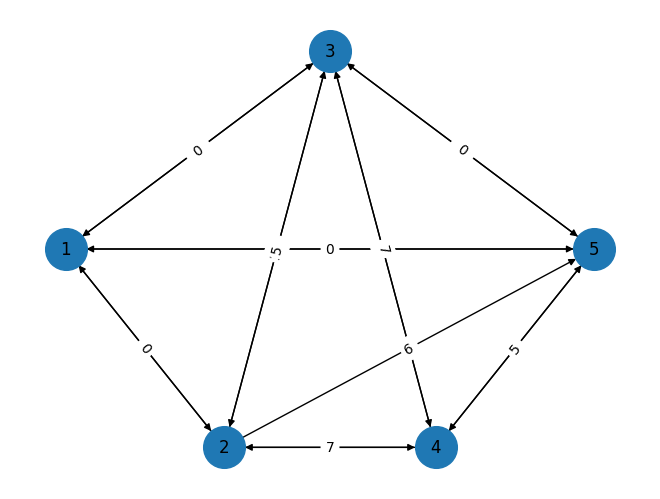

In [11]:
# Línea de posicionamiento de los nodos en el espacio del diagrama.
pos_f = {
    1: (-2, 0), 2: (-0.8, -1.5), 3: (0, 1.5),
    4: (0.8, -1.5), 5: (2, 0)
}

# Líneas de grafiación.
nx.draw(F, pos_f, with_labels=True, node_size=900, arrows=True)
nx.draw_networkx_edge_labels(F, pos_f,
    edge_labels=nx.get_edge_attributes(F, 'capacity'))
plt.show()


## 3.3. Solución al problema el flujo máximo

La función a usar es:

```python
nx.maximum_flow(F, source, sink, capacity='capacity')
```

Devuelve dos objetos:

1. el **valor del flujo máximo**;
2. un diccionario con el **flujo enviado por cada arco**.

Veámoslo a continuación.

In [12]:
fuente = 1
sumidero = 5

# Función que resuelve el problema.
valor, flujo = nx.maximum_flow(F, fuente, sumidero, capacity='capacity')

print("Flujo máximo:", valor)
print("Flujo por los arcos:")
for u in flujo:
    for v in flujo[u]:
        if flujo[u][v] > 0:
            print(f"{u} -> {v}: {flujo[u][v]}")


Flujo máximo: 25
Flujo por los arcos:
1 -> 3: 13
1 -> 2: 8
1 -> 5: 4
3 -> 5: 10
3 -> 4: 5
4 -> 5: 5
2 -> 3: 2
2 -> 5: 6


### Resultados

La función arroja los resultados:

$$
\boxed{|f|=25}.
$$

Que es el resultado al problema de flujo máximo.